# Cardiovascular Disease Prediction

The data consists of three types of data namely,
factual information, results of medical examination (Examination feature), and information given
by patients (subjective features). Also, the data in the dataset is divided into categorical and
numerical data. The dataset comprises 70000 data points and 14 features.

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing
import seaborn as sns   # data visualization
import matplotlib.pyplot as plt
from matplotlib import rcParams

In [ ]:
data = pd.read_csv("carvas.csv")   # loading the  data
data.head()

,id,age,"gender 1:women,2:men",height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
data.columns.values  # gives the label for each column

array(['id', 'age', 'gender 1:women,2:men', 'height', 'weight', 'ap_hi',
       'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active',
       'cardio'], dtype=object)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    70000 non-null  int64  
 1   age                   70000 non-null  int64  
 2   gender 1:women,2:men  70000 non-null  int64  
 3   height                70000 non-null  int64  
 4   weight                70000 non-null  float64
 5   ap_hi                 70000 non-null  int64  
 6   ap_lo                 70000 non-null  int64  
 7   cholesterol           70000 non-null  int64  
 8   gluc                  70000 non-null  int64  
 9   smoke                 70000 non-null  int64  
 10  alco                  70000 non-null  int64  
 11  active                70000 non-null  int64  
 12  cardio                70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


# Data Preprocessing

In [ ]:
#Shape (rows,columns) of the data
data.shape

(70000, 13)

The dataset is void of any missing values.

In [ ]:
data.isna().any()

id                      False
age                     False
gender 1:women,2:men    False
height                  False
weight                  False
ap_hi                   False
ap_lo                   False
cholesterol             False
gluc                    False
smoke                   False
alco                    False
active                  False
cardio                  False
dtype: bool

In [ ]:
# Statistical description of the dataset
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,52.840671,6.766774,29.0,48.00,53.0,58.00,64.0
"gender 1:women,2:men",70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


In [ ]:
data.cardio.value_counts()   # to find the frequency of unique values

0    35021
1    34979
Name: cardio, dtype: int64

# Data Visualization

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


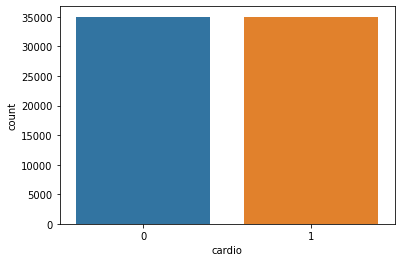

In [ ]:
sns.countplot(data['cardio'])   # Show the counts of observations in each categorical bin using bars
plt.show()

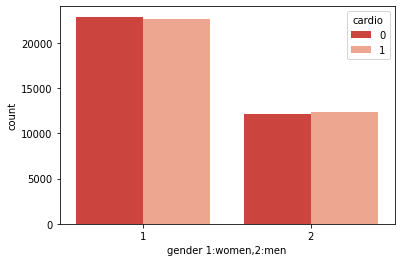

In [ ]:
sns.countplot(x='gender 1:women,2:men', hue='cardio', data=data,palette='Reds_r')
plt.show()

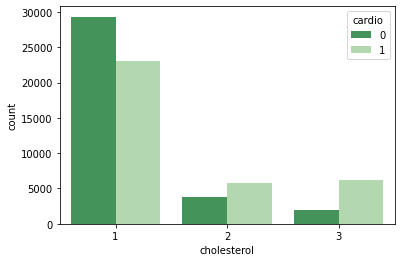

In [ ]:
sns.countplot(x='cholesterol', hue='cardio', data=data, palette='Greens_r')
plt.show()

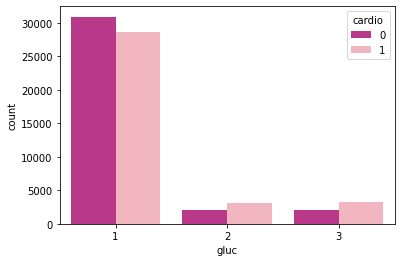

In [ ]:
sns.countplot(x='gluc', hue='cardio', data=data, palette='RdPu_r')
plt.show()

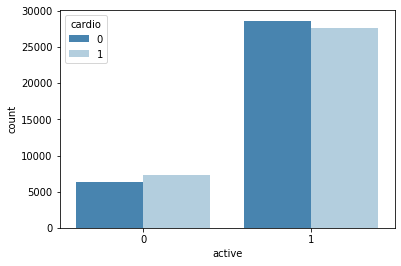

In [ ]:
sns.countplot(x='active', hue='cardio', data=data, palette='Blues_r')
plt.show()

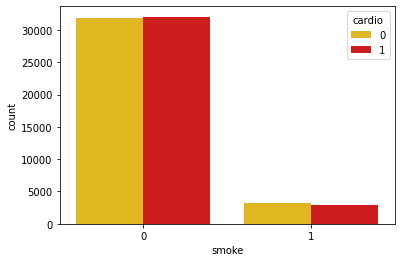

In [ ]:
sns.countplot(x='smoke', hue='cardio', data=data,palette='hot_r' )
plt.show()

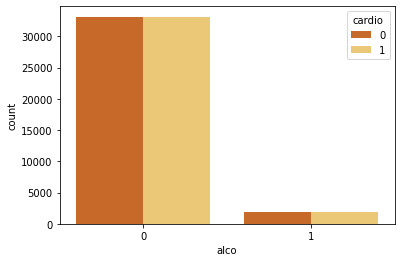

In [ ]:
sns.countplot(x='alco', hue='cardio', data=data, palette='YlOrBr_r')
plt.show()

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


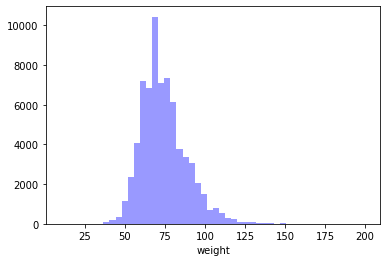

In [ ]:
sns.distplot(data['weight'], kde=False,color='blue')
plt.show()

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


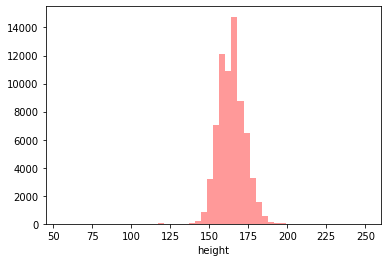

In [ ]:
sns.distplot(data['height'], kde=False,color='red')
plt.show()

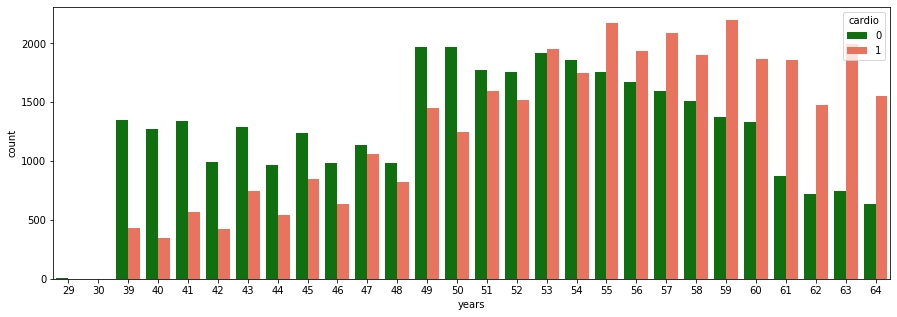

In [ ]:
rcParams['figure.figsize'] = 15, 5
data['years'] = (data['age']).round().astype('int')
sns.countplot(x='years', hue='cardio', data = data, palette=["#008000", "#FF6347"]);

The “id”
feature, due to its redundancy was removed from the dataset.

In [ ]:
data=pd.read_csv('carvas.csv').drop(["id"],axis=1)
data.head()

,age,"gender 1:women,2:men",height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,70000.0,52.840671,6.766774,29.0,48.0,53.0,58.0,64.0
"gender 1:women,2:men",70000.0,1.349571,0.476838,1.0,1.0,1.0,2.0,2.0
height,70000.0,164.359229,8.210126,55.0,159.0,165.0,170.0,250.0
weight,70000.0,74.205690,14.395757,10.0,65.0,72.0,82.0,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.0,120.0,140.0,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.0,80.0,90.0,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.0,1.0,2.0,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.0,1.0,1.0,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.0,0.0,0.0,1.0
alco,70000.0,0.053771,0.225568,0.0,0.0,0.0,0.0,1.0


# Data Cleaning

A probe of the above table revealed that the data had some outliers which were to
be removed to obtain accurate results. The presence of outliers was confirmed by
plotting boxplots for every quantitative attribute in the dataset.

In [ ]:
a=data['height'].max()
b=data['weight'].max()
c=data['height'].min()
d=data['weight'].min()
print(" Max height: ",a)
print(" Max weight: ",b)
print(" Min height: ",c)
print(" Min weight: ",d)

 Max height:  250
 Max weight:  200.0
 Min height:  55
 Min weight:  10.0


In [ ]:
x=data['ap_hi'].min()
y=data['ap_lo'].min()
print(" Min ap_hi: ",x)
print(" Min ap_lo: ",y)

 Min ap_hi:  -150
 Min ap_lo:  -70


In [ ]:
mean_height = data['height'].mean()
mean_height

164.35922857142856

In [ ]:
data['height'].fillna(mean_height,inplace=True)

In [ ]:
import plotly.express as ps
fig=ps.box(data,y='height')
fig.show()

In [ ]:
Q1=data['height'].quantile(0.25)
Q3=data['height'].quantile(0.75)
IQR =Q3-Q1
print(IQR)
LowerFence=Q1-(1.5*IQR)
UpperFence=Q3+(1.5*IQR)
print(LowerFence)
print(UpperFence)

11.0
142.5
186.5


In [ ]:
data=data[~((data['height']<LowerFence)|(data['height']>UpperFence))]

In [ ]:
fig=ps.box(data,y='height')
fig.show()

In [ ]:
mean_weight = data['weight'].mean()
mean_weight

74.15255537485069

In [ ]:
data['weight'].fillna(mean_weight,inplace=True)

In [ ]:
import plotly.express as ps
fig=ps.box(data,y='weight')
fig.show()

In [ ]:
Q1=data['weight'].quantile(0.25)
Q3=data['weight'].quantile(0.75)
IQR =Q3-Q1
print(IQR)
LowerFence=Q1-(1.5*IQR)
UpperFence=Q3+(1.5*IQR)
print(LowerFence)
print(UpperFence)

17.0
39.5
107.5


In [ ]:
data=data[~((data['weight']<LowerFence)|(data['weight']>UpperFence))]

In [ ]:
fig=ps.box(data,y='weight')
fig.show()

In [ ]:
Q1=data['weight'].quantile(0.25)
Q3=data['weight'].quantile(0.75)
IQR =Q3-Q1
print(IQR)
LowerFence=Q1-(1.5*IQR)
UpperFence=Q3+(1.5*IQR)
print(LowerFence)
print(UpperFence)

16.0
41.0
105.0


In [ ]:
data=data[~((data['weight']<LowerFence)|(data['weight']>UpperFence))]

In [ ]:
fig=ps.box(data,y='weight')
fig.show()

In [ ]:
Q1=data['weight'].quantile(0.25)
Q3=data['weight'].quantile(0.75)
IQR =Q3-Q1
print(IQR)
LowerFence=Q1-(1.5*IQR)
UpperFence=Q3+(1.5*IQR)
print(LowerFence)
print(UpperFence)

15.0
42.5
102.5


In [ ]:
data=data[~((data['weight']<LowerFence)|(data['weight']>UpperFence))]

In [ ]:
fig=ps.box(data,y='weight')
fig.show()

In [ ]:
mean_ap_hi = data['ap_hi'].mean()
mean_ap_hi

128.27556890724748

In [ ]:
data['ap_hi'].fillna(mean_ap_hi,inplace=True)

In [ ]:
fig=ps.box(data,y='ap_hi')
fig.show()

In [ ]:
Q1=data['ap_hi'].quantile(0.25)
Q3=data['ap_hi'].quantile(0.75)
IQR =Q3-Q1
print(IQR)
LowerFence=Q1-(1.5*IQR)
UpperFence=Q3+(1.5*IQR)
print(LowerFence)
print(UpperFence)

20.0
90.0
170.0


In [ ]:
data=data[~((data['ap_hi']<LowerFence)|(data['ap_hi']>UpperFence))]

In [ ]:
fig=ps.box(data,y='ap_hi')
fig.show()

In [ ]:
mean_ap_lo = data['ap_lo'].mean()
mean_ap_lo

93.72645568263592

In [ ]:
data['ap_lo'].fillna(mean_ap_lo,inplace=True)

In [ ]:
fig=ps.box(data,y='ap_lo')
fig.show()

In [ ]:
Q1=data['ap_lo'].quantile(0.25)
Q3=data['ap_lo'].quantile(0.75)
IQR =Q3-Q1
print(IQR)
LowerFence=Q1-(1.5*IQR)
UpperFence=Q3+(1.5*IQR)
print(LowerFence)
print(UpperFence)

10.0
65.0
105.0


In [ ]:
data=data[~((data['ap_lo']<LowerFence)|(data['ap_lo']>UpperFence))]

In [ ]:
fig=ps.box(data,y='ap_lo')
fig.show()

In [ ]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,61475.0,52.905197,6.740627,29.0,48.0,54.0,58.0,64.0
"gender 1:women,2:men",61475.0,1.347312,0.476120,1.0,1.0,1.0,2.0,2.0
height,61475.0,164.368312,7.496449,143.0,159.0,165.0,170.0,186.0
weight,61475.0,72.746267,11.669482,43.0,65.0,71.0,80.0,102.0
ap_hi,61475.0,126.310858,14.239173,90.0,120.0,120.0,140.0,170.0
ap_lo,61475.0,81.649418,7.654213,65.0,80.0,80.0,90.0,105.0
cholesterol,61475.0,1.354616,0.673000,1.0,1.0,1.0,1.0,3.0
gluc,61475.0,1.218935,0.566040,1.0,1.0,1.0,1.0,3.0
smoke,61475.0,0.085986,0.280346,0.0,0.0,0.0,0.0,1.0
alco,61475.0,0.051712,0.221447,0.0,0.0,0.0,0.0,1.0


A new feature, “BMI” was added as the derived feature of the two existing features
namely, “height” and “weight”, since the BMI value has a considerable effect on a
person’s cardiac muscles.

In [ ]:
#adding a new feature (bmi) derived from the existing features (height and weight)
data["bmi"] = data["weight"] / (data["height"]/100)**2

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



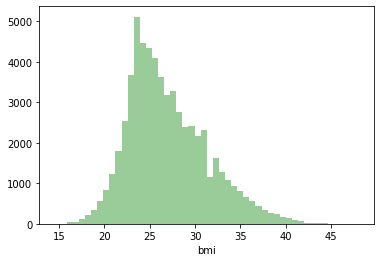

In [ ]:
sns.distplot(data['bmi'], bins=50, kde=False,color='green')
plt.show()

In [ ]:
data['pulse pressure'] = data['ap_hi'] - data['ap_lo']

In [ ]:
data.head()

,age,"gender 1:women,2:men",height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi,pulse pressure
0,50,2,168,62.0,110,80,1,1,0,0,1,0,21.967120,30
1,55,1,156,85.0,140,90,3,1,0,0,1,1,34.927679,50
2,51,1,165,64.0,130,70,3,1,0,0,0,1,23.507805,60
3,48,2,169,82.0,150,100,1,1,0,0,1,1,28.710479,50
5,60,1,151,67.0,120,80,2,2,0,0,0,0,29.384676,40


In [ ]:
mean_bmi = data['bmi'].mean()
mean_bmi

26.977011327778797

In [ ]:
data['bmi'].fillna(mean_bmi,inplace=True)


In [ ]:
fig=ps.box(data,y='bmi')
fig.show()

In [ ]:
Q1=data['bmi'].quantile(0.25)
Q3=data['bmi'].quantile(0.75)
IQR =Q3-Q1
print(IQR)
LowerFence=Q1-(1.5*IQR)
UpperFence=Q3+(1.5*IQR)
print(LowerFence)
print(UpperFence)

5.79285643154989
15.185830136880861
38.35725586308042


In [ ]:
data=data[~((data['bmi']<LowerFence)|(data['bmi']>UpperFence))]

In [ ]:
fig=ps.box(data,y='bmi')
fig.show()

In [ ]:
Q1=data['bmi'].quantile(0.25)
Q3=data['bmi'].quantile(0.75)
IQR =Q3-Q1
print(IQR)
LowerFence=Q1-(1.5*IQR)
UpperFence=Q3+(1.5*IQR)
print(LowerFence)
print(UpperFence)

5.574148297715951
15.46690255342607
37.76349574428987


In [ ]:
data=data[~((data['bmi']<LowerFence)|(data['bmi']>UpperFence))]

In [ ]:
fig=ps.box(data,y='bmi')
fig.show()

In [ ]:
mean_pp = data['pulse pressure'].mean()
mean_pp

44.57830745753716

In [ ]:
data['pulse pressure'].fillna(mean_pp,inplace=True)


In [ ]:
fig=ps.box(data,y='pulse pressure')
fig.show()

In [ ]:
Q1=data['pulse pressure'].quantile(0.25)
Q3=data['pulse pressure'].quantile(0.75)
IQR =Q3-Q1
print(IQR)
LowerFence=Q1-(1.5*IQR)
UpperFence=Q3+(1.5*IQR)
print(LowerFence)
print(UpperFence)

10.0
25.0
65.0


In [ ]:
data=data[~((data['pulse pressure']<LowerFence)|(data['pulse pressure']>UpperFence))]

In [ ]:
fig=ps.box(data,y='pulse pressure')
fig.show()

In [ ]:
#Shape (rows,columns) of the data
data.shape

(56637, 14)

In [ ]:
data.isna().any()

age                     False
gender 1:women,2:men    False
height                  False
weight                  False
ap_hi                   False
ap_lo                   False
cholesterol             False
gluc                    False
smoke                   False
alco                    False
active                  False
cardio                  False
bmi                     False
pulse pressure          False
dtype: bool

In [ ]:
from google.colab import drive
drive.mount('drive')

Mounted at drive


In [ ]:
data.to_csv('data.csv')
!cp data.csv "drive/My Drive/"

In [ ]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,56637.0,52.796900,6.738537,29.000000,48.00000,53.000000,58.00000,64.000000
"gender 1:women,2:men",56637.0,1.352949,0.477891,1.000000,1.00000,1.000000,2.00000,2.000000
height,56637.0,164.596624,7.406460,143.000000,160.00000,165.000000,170.00000,186.000000
weight,56637.0,72.221654,11.275599,43.000000,65.00000,71.000000,80.00000,102.000000
ap_hi,56637.0,125.032947,12.313162,90.000000,120.00000,120.000000,130.00000,168.000000
ap_lo,56637.0,81.420697,7.562991,65.000000,80.00000,80.000000,90.00000,105.000000
cholesterol,56637.0,1.341561,0.663879,1.000000,1.00000,1.000000,1.00000,3.000000
gluc,56637.0,1.214771,0.562869,1.000000,1.00000,1.000000,1.00000,3.000000
smoke,56637.0,0.086304,0.280815,0.000000,0.00000,0.000000,0.00000,1.000000
alco,56637.0,0.051680,0.221382,0.000000,0.00000,0.000000,0.00000,1.000000


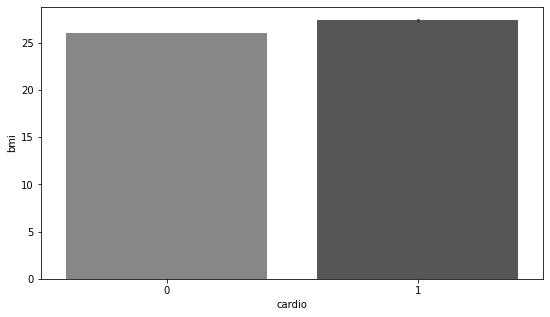

In [ ]:
fig = plt.figure(figsize = (9,5))
sns.barplot(x = 'cardio', y = 'bmi', data = data,palette='Greys_d')

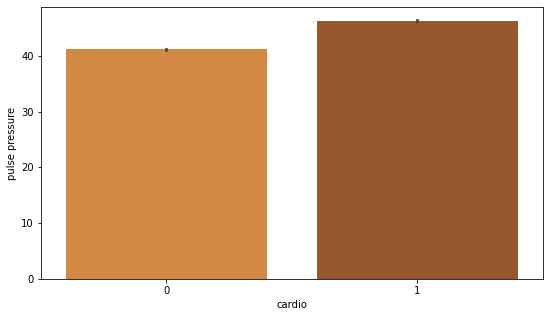

In [ ]:
fig = plt.figure(figsize = (9,5))
sns.barplot(x = 'cardio', y = 'pulse pressure', data = data,palette='YlOrBr_d')

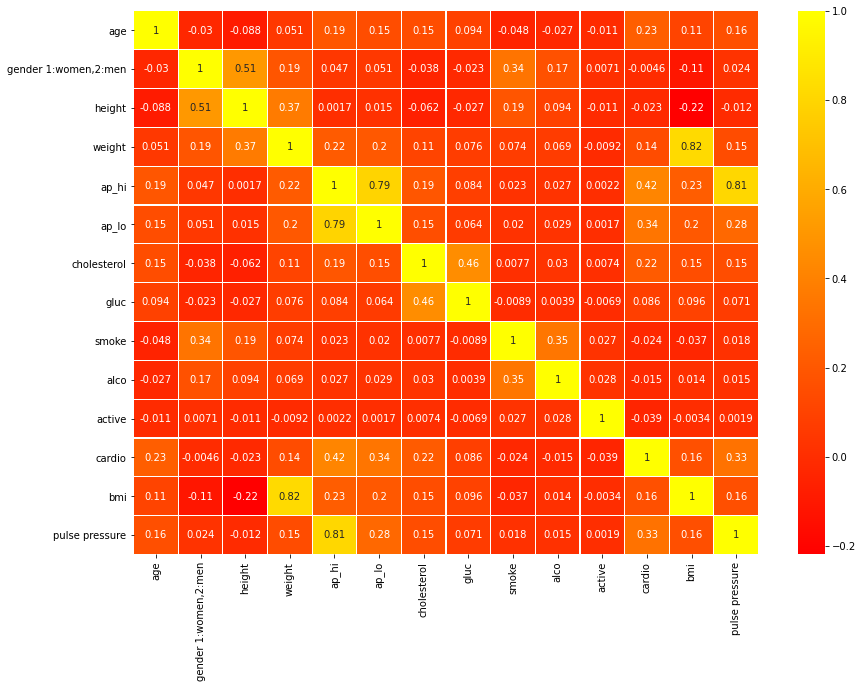

In [ ]:
correlation=data.corr()
colormap=plt.cm.autumn
plt.figure(figsize=(14,10))
sns.heatmap(correlation,cmap=colormap, annot=True, linewidths=0.2)   #annot=true to display correlation

In [ ]:
#standardization the dataset by removing the mean and scaling to unit varience
from sklearn.preprocessing import StandardScaler
standardScaler = StandardScaler()
scale_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo','bmi']
data[scale_columns] = standardScaler.fit_transform(data[scale_columns])
data

,age,"gender 1:women,2:men",height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
0,-0.420858,2,0.504405,-0.983822,-1.145970,-0.126993,1,1,0,0,1,0,-1.181393
1,0.320099,1,-1.252519,0.996426,1.033989,1.086733,3,1,0,0,1,1,1.761144
2,-0.272666,1,0.065174,-0.811626,0.307336,-1.340720,3,1,0,0,0,1,-0.831599
3,-0.717240,2,0.650816,0.738133,1.760641,2.300460,1,1,0,0,1,1,0.349605
4,-0.865432,1,-1.252519,-1.500408,-1.872622,-2.554446,1,1,0,0,0,0,-0.944353
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,0.023716,1,1.090047,-0.295040,0.307336,1.086733,1,1,0,0,1,1,-0.796719
69994,0.616482,1,0.065174,0.565937,1.760641,-0.126993,1,1,0,0,1,1,0.502691
69995,-0.124475,2,0.504405,0.221546,-0.419317,-0.126993,1,1,1,0,1,0,-0.055213
69998,1.209247,1,-0.227647,-0.122845,0.670662,-0.126993,1,2,0,0,0,1,-0.016205


In [ ]:
#Now seperate the dataset as response variable and feature variabes
X = data.drop('cardio', axis = 1)   # dropping the 'quality' column
y = data['cardio']

In [ ]:
#Train and Test splitting of data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)    # scale the training data and also learn the scaling parameters of that data.
X_test=sc.transform(X_test)          # the parameters learned by the model using the training data will help to transform the test data.
print(X_train)
print("##############################")
print(X_test)

[[ 0.9235401   1.35149415  2.48701794 ...  0.49495    -0.6211496
  -0.4592364 ]
 [-1.45566573  1.35149415  0.45548886 ...  0.49495    -1.17354649
  -0.4592364 ]
 [-1.75306646 -0.73992181 -0.49255805 ...  0.49495    -0.11190504
  -0.4592364 ]
 ...
 [ 0.47743901  1.35149415  1.26810049 ...  0.49495    -1.29745913
  -0.4592364 ]
 [-1.00956464 -0.73992181 -0.2216875  ...  0.49495    -1.11402238
  -0.4592364 ]
 [-0.56346354  1.35149415  0.32005358 ...  0.49495     0.23046698
  -0.4592364 ]]
##############################
[[-0.11736245  1.35149415  0.18461831 ...  0.49495    -1.40224455
  -0.4592364 ]
 [ 0.18003828 -0.73992181 -1.98234605 ...  0.49495    -0.0041316
   0.81995161]
 [ 0.9235401   1.35149415  1.40353576 ...  0.49495    -0.30205733
  -0.4592364 ]
 ...
 [ 0.9235401   1.35149415  1.40353576 ...  0.49495    -0.22080486
   0.81995161]
 [-1.45566573 -0.73992181  0.45548886 ...  0.49495    -0.46822991
  -0.4592364 ]
 [ 1.51834156 -0.73992181 -0.35712278 ...  0.49495    -0.19224698
   

In [ ]:
import pandas as pd
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
X= data.drop("cardio",axis=1)    # all featured variables
y= data["cardio"]                # only target variables
predictors = data.head(0)
selector = SelectKBest(chi2, k=5)   # k='all' or k=5 etc
sf_fit = selector.fit(X,y)  # will be used for plotting
# print features scores
for i in range(len(sf_fit.scores_)):
  print(data.columns[i],':',sf_fit.scores_[i])

age : 2652.839954704656
gender 1:women,2:men : 0.2065215709078265
height : 9.665988166796595
weight : 2080.23437400631
ap_hi : 12019.321016947051
ap_lo : 4660.566904078445
cholesterol : 876.0530862525134
gluc : 108.8525904148211
smoke : 29.88888306703523
alco : 11.3885608376964
active : 16.44270813433166
cardio : 932.9459903095556
bmi : 8528.744037994828


/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning:

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



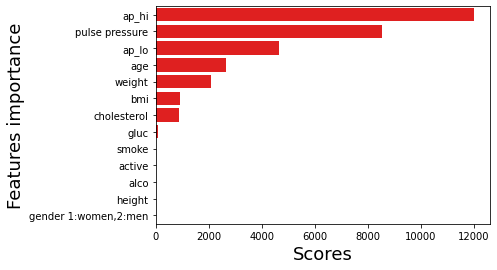

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
datset=pd.DataFrame()
datset['feature']=X.columns[range(len(sf_fit.scores_))]
datset['scores']=sf_fit.scores_
datset=datset.sort_values(by='scores',ascending=False)
sns.barplot(datset['scores'],datset['feature'],color='red')
#sns.set_style('whitegrid')
plt.ylabel('Features importance',fontsize=18)
plt.xlabel('Scores',fontsize=18)
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='entropy',max_depth=3)
model.fit(X_train,y_train)    # learning the relationship between X_train and y_train.
y_pred = model.predict(X_test)   # prediction

Text(91.68, 0.5, 'Predicted class')

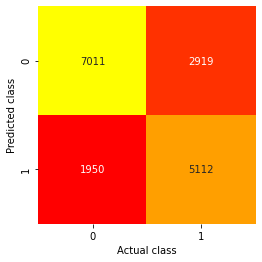

In [ ]:
# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as pt
from sklearn.metrics import confusion_matrix
conmat=confusion_matrix(y_test,y_pred) # Compute confusion matrix to evaluate the accuracy of a classification.
sns.heatmap(conmat.T, square=True, annot=True, fmt='d', cbar=False,cmap='autumn') # square=True means cell will be square-shaped.
pt.xlabel('Actual class')
pt.ylabel('Predicted class')

In [ ]:
import sklearn.metrics as met
from sklearn.metrics import accuracy_score,classification_report
cr = classification_report(y_test,y_pred) # text report showing the main classification metrics.
print(cr)
accuracyscore=met.accuracy_score(y_test, y_pred)*100  #accuracy score in percentage multiply by 100
print('\n')
print('Accuracy score given for test data:',str(accuracyscore))

              precision    recall  f1-score   support

           0       0.71      0.78      0.74      8961
           1       0.72      0.64      0.68      8031

    accuracy                           0.71     16992
   macro avg       0.71      0.71      0.71     16992
weighted avg       0.71      0.71      0.71     16992



Accuracy score given for test data: 71.34533898305084


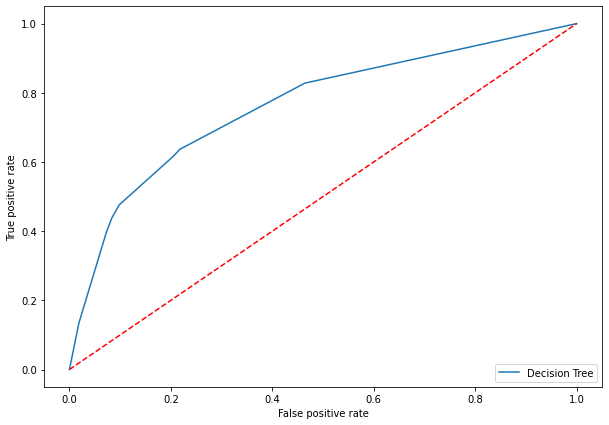

In [ ]:
from sklearn.metrics import roc_auc_score,roc_curve
fpr,tpr,thresholds=roc_curve(y_test,model.predict_proba(X_test)[:,1])
model_roc_auc=roc_auc_score(y_test,model.predict_proba(X_test)[:,1])

import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.plot(fpr,tpr,label='Decision Tree'%model_roc_auc)
plt.plot([0,1],[0,1],'r--')    # red color in dashed
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend(loc="lower right")
plt.show()

/usr/local/lib/python3.7/dist-packages/sklearn/externals/six.py:31: FutureWarning:

The module is deprecated in version 0.21 and will be removed in version 0.23 since we've dropped support for Python 2.7. Please rely on the official version of six (https://pypi.org/project/six/).



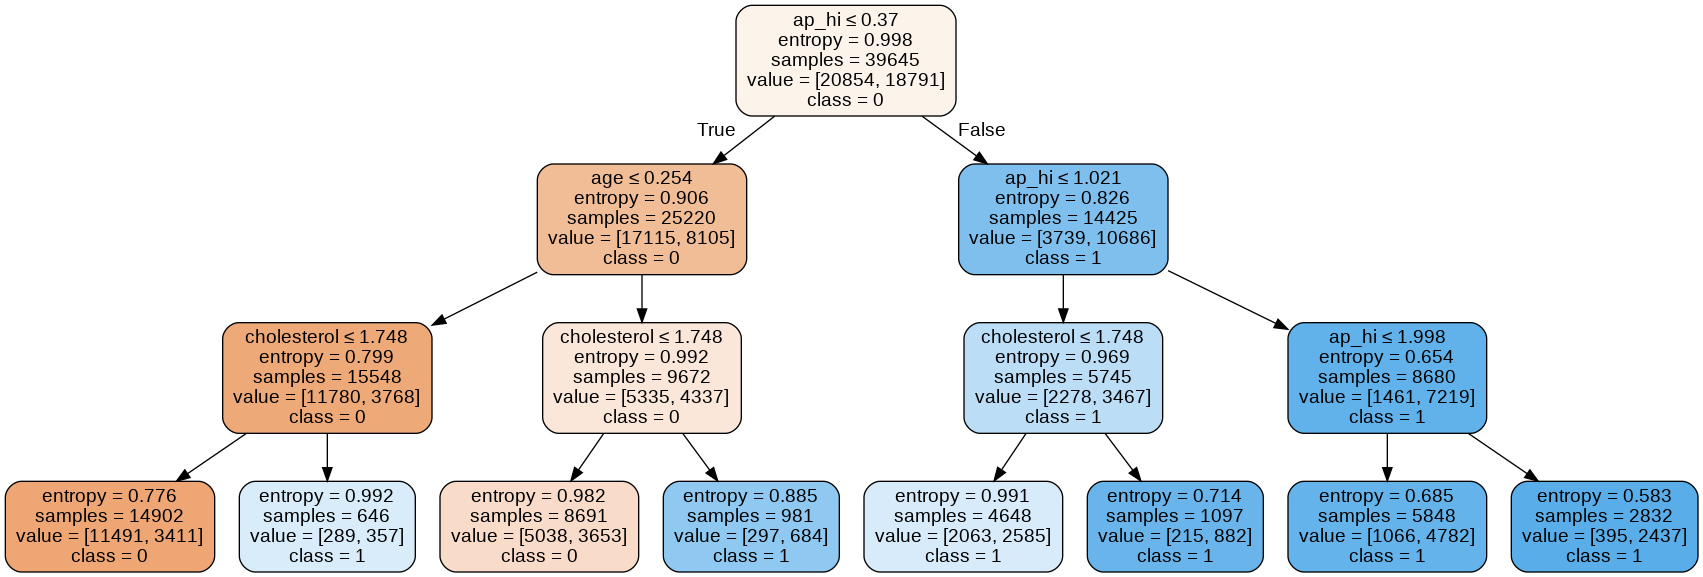

In [ ]:
feature_cols = ['age','gender 1:women,2:men','height','weight','ap_hi','ap_lo','cholesterol','gluc','smoke', 'alco', 'active','bmi','pulse pressure']

from sklearn import tree
import matplotlib.image as pltimg
from sklearn.externals.six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
dot_data = StringIO()
export_graphviz(model, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True, feature_names = feature_cols,class_names=['0','1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('carvas.png')
Image(graph.create_png())

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model1 = RandomForestClassifier(random_state=1)
model1.fit(X_train, y_train)     # learning the relationship between X_train and y_train.
y_pred1 = model1.predict(X_test)    # prediction

Text(91.68, 0.5, 'Predicted class')

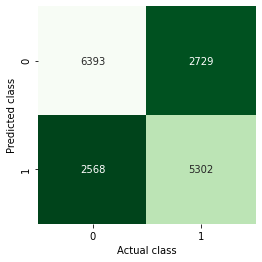

In [ ]:
# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as pt
from sklearn.metrics import confusion_matrix
conmat=confusion_matrix(y_test,y_pred1) # Compute confusion matrix to evaluate the accuracy of a classification.
sns.heatmap(conmat.T, square=True, annot=True, fmt='d', cbar=False,cmap='Greens_r') # square=True, set the Axes aspect to “equal” so each cell will be square-shaped.    # annot=True write the data value in each cell.  # cbar=False means Whether to draw a colorbar.
pt.xlabel('Actual class')
pt.ylabel('Predicted class')

In [ ]:
import sklearn.metrics as met
from sklearn.metrics import accuracy_score,classification_report
cr = classification_report(y_test,y_pred1) # text report showing the main classification metrics.
print(cr)
accuracyscore=met.accuracy_score(y_test, y_pred1)*100 # accuracy score in percentage multiply by 100
print('\n')
print('Accuracy score given for test data:',str(accuracyscore))

              precision    recall  f1-score   support

           0       0.70      0.71      0.71      8961
           1       0.67      0.66      0.67      8031

    accuracy                           0.69     16992
   macro avg       0.69      0.69      0.69     16992
weighted avg       0.69      0.69      0.69     16992



Accuracy score given for test data: 68.8265065913371


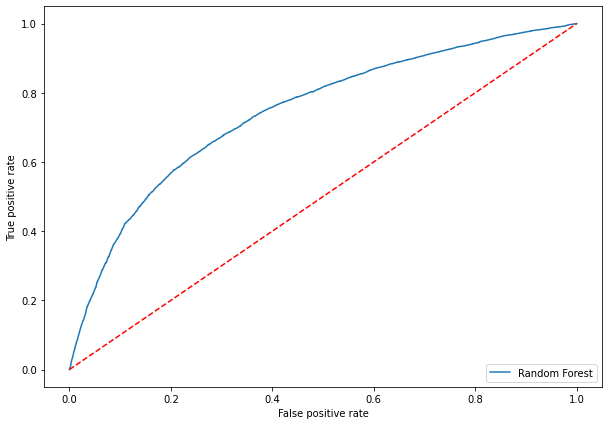

In [ ]:
from sklearn.metrics import roc_auc_score,roc_curve
fpr,tpr,thresholds=roc_curve(y_test,model1.predict_proba(X_test)[:,1])
model1_roc_auc=roc_auc_score(y_test,model1.predict_proba(X_test)[:,1])

import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.plot(fpr,tpr,label='Random Forest'%model1_roc_auc)
plt.plot([0,1],[0,1],'r--')    # red color in dashed
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
model3 = LogisticRegression()    # Making an instance of the Model.
model3.fit(X_train,y_train)      # learning the relationship between X_train and y_train.
y_pred3 = model3.predict(X_test)  # prediction

In [ ]:
import sklearn.metrics as met
from sklearn.metrics import accuracy_score,classification_report
cr = classification_report(y_test,y_pred3)   # text report showing the main classification metrics.
print(cr)
accuracyscore=met.accuracy_score(y_test, y_pred3)*100 # accuracy score in percentage multiply by 100
print('\n')
print('Accuracy score given for test data:',str(accuracyscore))

              precision    recall  f1-score   support

           0       0.71      0.79      0.75      8961
           1       0.73      0.63      0.68      8031

    accuracy                           0.72     16992
   macro avg       0.72      0.71      0.71     16992
weighted avg       0.72      0.72      0.71     16992



Accuracy score given for test data: 71.70433145009416


Text(91.68, 0.5, 'Predicted class')

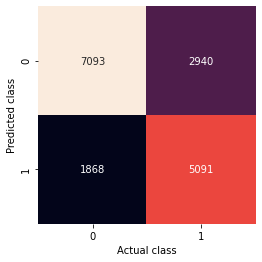

In [ ]:
# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as pt
from sklearn.metrics import confusion_matrix
conmat=confusion_matrix(y_test,y_pred3)   # Compute confusion matrix to evaluate the accuracy of a classification.
sns.heatmap(conmat.T, square=True, annot=True, fmt='d', cbar=False) # square=True, set the Axes aspect to “equal” so each cell will be square-shaped.    # annot=True write the data value in each cell.  # cbar=False means Whether to draw a colorbar.
pt.xlabel('Actual class')
pt.ylabel('Predicted class')

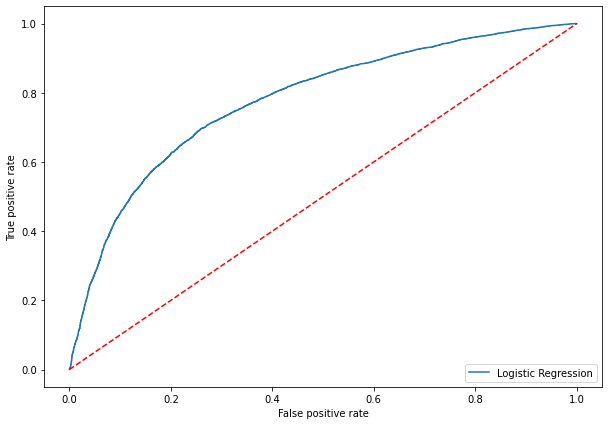

In [ ]:
from sklearn.metrics import roc_auc_score,roc_curve
fpr,tpr,thresholds=roc_curve(y_test,model3.predict_proba(X_test)[:,1])
model3_roc_auc=roc_auc_score(y_test,model3.predict_proba(X_test)[:,1])

import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.plot(fpr,tpr,label='Logistic Regression'%model3_roc_auc)
plt.plot([0,1],[0,1],'r--')    # red color in dashed
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend(loc="lower right")
plt.show()